## 1. 数据处理

先导入后续所需的库，设置Dataframe的显示格式。

In [26]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#显示 DataFrame 时，不限制列数，展示所有字段
pd.set_option("display.max_columns", None)
#文本形式表格的显示宽度设为 120 个字符
pd.set_option("display.width", 120)

print("Pandas 版本：", pd.__version__)
print("当前工作目录：", Path.cwd())

Pandas 版本： 3.0.5
当前工作目录： /Users/clearlove7/Documents/AI introduction/Hull Tactical Competition/notebooks


导入数据并对数据做初步认知。

In [27]:
df = pd.read_csv("../archive/spy-historical.csv")

#显示前五行
display(df.head())

print("数据行数：", df.shape[0])
print("数据列数：", df.shape[1])

#把全部字段名称转换成普通列表
print("字段名称：")
print(df.columns.tolist())

#返回每列是否有空值，以及数据类型
df.info()

,date_id,Date,Open,High,Low,Close,Adj Close,Volume,Dividend,forward_returns
0,780,1993-02-01,43.97,44.25,43.97,44.25,24.49,480500.0,0.0,0.002034
1,781,1993-02-02,44.22,44.38,44.13,44.34,24.54,201300.0,0.0,0.010600
2,782,1993-02-03,44.41,44.84,44.38,44.81,24.80,529400.0,0.0,0.004240
3,783,1993-02-04,44.97,45.09,44.47,45.00,24.90,531500.0,0.0,-0.000667
4,784,1993-02-05,44.97,45.06,44.72,44.97,24.88,492100.0,0.0,0.000000


数据行数： 8210
数据列数： 10
字段名称：
['date_id', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume', 'Dividend', 'forward_returns']
<class 'pandas.DataFrame'>
RangeIndex: 8210 entries, 0 to 8209
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date_id          8210 non-null   int64  
 1   Date             8210 non-null   str    
 2   Open             8210 non-null   float64
 3   High             8210 non-null   float64
 4   Low              8210 non-null   float64
 5   Close            8210 non-null   float64
 6   Adj Close        8210 non-null   float64
 7   Volume           8210 non-null   float64
 8   Dividend         8210 non-null   float64
 9   forward_returns  8209 non-null   float64
dtypes: float64(8), int64(1), str(1)
memory usage: 641.5 KB


可以看到除了forward_returns以外，每列一共8210个数据，无空值。由于forward_return是未来反馈，交易日无下一日信息，少1个数据属正常现象。下面将数据集spy-historical.csv的前80%数据划分为训练集，后20%划分为测试集。

In [28]:
# 把字符串转换为真正的日期类型
df["Date"] = pd.to_datetime(
    df["Date"],
    format="%Y-%m-%d",
    errors="raise"
)

split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

print("训练集形状：", train_df.shape)
print("训练集日期：", train_df["Date"].iloc[0], "至", train_df["Date"].iloc[-1])

print("测试集形状：", test_df.shape)
print("测试集日期：", test_df["Date"].iloc[0], "至", test_df["Date"].iloc[-1])

训练集形状： (6568, 10)
训练集日期： 1993-02-01 00:00:00 至 2019-03-01 00:00:00
测试集形状： (1642, 10)
测试集日期： 2019-03-04 00:00:00 至 2025-09-11 00:00:00


## 2. 训练集探索性数据分析

#### 2.1 数据分析与特征构建

先计算收益率，其中Close是当天市场收盘价，Adj Close是经过拆股、分红等因素调整后的价格。我们研究的是投资者实际获得的历史收益，因此使用 Adj Close 计算收益率更合理。

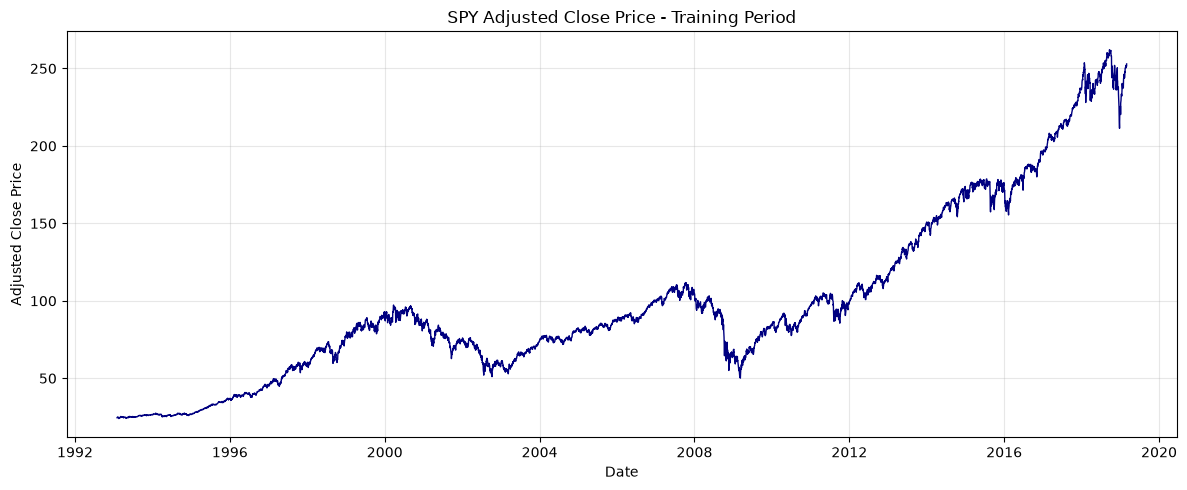

count    6567.000000
mean        0.000422
std         0.011524
min        -0.098435
25%        -0.004325
50%         0.000648
75%         0.005760
max         0.145291
Name: Daily_Return, dtype: float64

In [29]:
#计算每日收益率
train_df["Daily_Return"] = train_df["Adj Close"].pct_change()

#绘制复权收盘价曲线
plt.figure(figsize=(12, 5))

plt.plot(
    train_df["Date"],
    train_df["Adj Close"],
    color="navy",
    linewidth=1
)

plt.title("SPY Adjusted Close Price - Training Period")
plt.xlabel("Date")
plt.ylabel("Adjusted Close Price")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#查看收益率统计
train_df["Daily_Return"].describe()

可以从收益率的数据看出，年化平均收益约为：0.000422 × 252 = 10.63%，年化波动率约为：0.011524 × √252 = 18.29%。同时可以看出SPY虽然长期有正收益，但单日的随机波动远大于平均上涨幅度，所以预测下一日涨跌非常困难。

In [30]:
daily_returns = train_df["Daily_Return"].dropna()

up_days = (daily_returns > 0).sum()
down_days = (daily_returns < 0).sum()
flat_days = (daily_returns == 0).sum()

up_rate = up_days / len(daily_returns)
down_rate = down_days / len(daily_returns)
flat_rate = flat_days / len(daily_returns)

print("上涨日数量：", up_days)
print("下跌日数量：", down_days)
print("平盘日数量：", flat_days)

print("上涨日比例：", f"{up_rate:.2%}")
print("下跌日比例：", f"{down_rate:.2%}")
print("平盘日比例：", f"{flat_rate:.2%}")

上涨日数量： 3523
下跌日数量： 2969
平盘日数量： 75
上涨日比例： 53.65%
下跌日比例： 45.21%
平盘日比例： 1.14%


我们做一个小验算，数据集中forward_returns通常有多种含义，或者说计算方式，例如
1. 下一日收盘价收益
2. 下一日含分红收益
3. 下一日开盘到收盘收益
4. 简单收益率
5. 对数收益率

经过以下验证，可以确认此刻采用的是第二种，下一日含分红收益在这份数据中的定义是：
$$
forward\_returns_t
=
\frac{Close_{t+1}+Dividend_{t+1}}{Close_t}-1
$$
也就是“从今天收盘持有到下一交易日收盘的含分红简单收益率”。

In [32]:
calculated_forward_returns = (
    (
        df["Close"].shift(-1)
        + df["Dividend"].shift(-1)
    )
    / df["Close"]
    - 1
)

max_difference = (
    df["forward_returns"]
    - calculated_forward_returns
).abs().max()

print("最大计算误差：", max_difference)

最大计算误差： 9.996344030316351e-17


接下来我们要回答下一个问题：已知今天收盘时及以前的信息，SPY 下一个交易日会上涨吗？这需要我们数据中的forward_returns表示当前行对应的下一交易日收益率。因此标签定义为：
$$
target =
\begin{cases}
1, & forward\_returns > 0 \\
0, & forward\_returns \le 0
\end{cases}
$$其中：
target = 1：下一日上涨；
target = 0：下一日下跌或平盘。
模型以后使用当前行的历史特征预测当前行的 target。
最后一个交易日没有下一日收益，因此不能作为训练样本。在这一步，我们会计算所有数据的整体特征。之后再分别划分进训练集和测试集。

In [31]:
#删去最后一个交易日
model_df = df.dropna(subset=["forward_returns"]).copy()

model_df["target"] = (
    model_df["forward_returns"] > 0
).astype(int)

display(
    model_df[
        ["Date", "Adj Close", "forward_returns", "target"]
    ].head()
)

,Date,Adj Close,forward_returns,target
0,1993-02-01,24.49,0.002034,1
1,1993-02-02,24.54,0.010600,1
2,1993-02-03,24.80,0.004240,1
3,1993-02-04,24.90,-0.000667,0
4,1993-02-05,24.88,0.000000,0


在接下来的步骤中，我们构建11个模型特征用于之后训练模型。包括：1日、5日、20日历史收益率，5日、20日、60日均线距离，5日、20日滚动波动率，日内收益率，日内振幅，20日相对成交量。

我们使用历史收益率来描述近期市场状态，以下我们分别计算1日，5日，20日历史收益率。

1日历史收益率
$$
return\_1d_t
=
\frac{AdjClose_t}{AdjClose_{t-1}}-1
$$

5日历史收益率
$$
return\_5d_t
=
\frac{AdjClose_t}{AdjClose_{t-5}}-1
$$

20日历史收益率
$$
return\_20d_t
=
\frac{AdjClose_t}{AdjClose_{t-20}}-1
$$

In [33]:
model_df["return_1d"] = (
    model_df["Adj Close"].pct_change(1)
)

model_df["return_5d"] = (
    model_df["Adj Close"].pct_change(5)
)

model_df["return_20d"] = (
    model_df["Adj Close"].pct_change(20)
)

display(
    model_df[
        [
            "Date",
            "Adj Close",
            "return_1d",
            "return_5d",
            "return_20d"
        ]
    ].iloc[18:23]
)

,Date,Adj Close,return_1d,return_5d,return_20d
18,1993-02-26,24.57,0.001222,0.019079,NaN
19,1993-03-01,24.50,-0.002849,0.012815,NaN
20,1993-03-02,24.87,0.015102,0.028962,0.015517
21,1993-03-03,24.97,0.004021,0.019600,0.017522
22,1993-03-04,24.83,-0.005607,0.011817,0.001210


我们使用移动平均线描述当前价格相对于近期趋势的位置。移动平均线就是过去若干交易日价格的平均值：
$$
MA_{20,t}
=
\frac{P_t+P_{t-1}+\cdots+P_{t-19}}{20}
$$
我们使用三个周期：
1. 5日均线：约一周的短期趋势
2. 20日均线：约一个月的中期趋势
3. 60日均线：约一个季度的较长期趋势

In [35]:
#计算均线
model_df["ma_5"] = (
    model_df["Adj Close"].rolling(5).mean()
)

model_df["ma_20"] = (
    model_df["Adj Close"].rolling(20).mean()
)

model_df["ma_60"] = (
    model_df["Adj Close"].rolling(60).mean()
)

#计算当前价格和均线的距离
model_df["distance_ma_5"] = (
    model_df["Adj Close"] / model_df["ma_5"] - 1
)

model_df["distance_ma_20"] = (
    model_df["Adj Close"] / model_df["ma_20"] - 1
)

model_df["distance_ma_60"] = (
    model_df["Adj Close"] / model_df["ma_60"] - 1
)

#查看60个交易日前后的结果
display(
    model_df[
        [
            "Date",
            "Adj Close",
            "ma_5",
            "ma_20",
            "ma_60",
            "distance_ma_5",
            "distance_ma_20",
            "distance_ma_60"
        ]
    ].iloc[58:63]
)

,Date,Adj Close,ma_5,ma_20,ma_60,distance_ma_5,distance_ma_20,distance_ma_60
58,1993-04-26,24.13,24.476,24.7775,NaN,-0.014136,-0.026133,NaN
59,1993-04-27,24.39,24.402,24.7435,24.759833,-0.000492,-0.014287,-0.014937
60,1993-04-28,24.34,24.322,24.7035,24.757333,0.000740,-0.014715,-0.016857
61,1993-04-29,24.45,24.326,24.6700,24.755833,0.005097,-0.008918,-0.012354
62,1993-04-30,24.48,24.358,24.6420,24.750500,0.005009,-0.006574,-0.010929


历史收益率描述市场过去涨跌了多少，但不能描述上涨或下跌过程是否稳定。因此需构建滚动波动率，例如，两段时间的5日总收益都是2%：
1. 每天平稳小幅上涨
2. 先大跌、再大涨，最终上涨2%

两段的累计收益相同，但第二段风险和不确定性更高。这种差异由波动率描述。滚动波动率就是过去若干交易日收益率的标准差：
$$
volatility_{20,t}
=
Std(r_t,r_{t-1},\ldots,r_{t-19})
$$

波动率越高，说明近期每日收益变化越剧烈；波动率越低，说明近期市场相对平稳。

In [36]:
#滚动波动率
model_df["volatility_5d"] = (
    model_df["return_1d"].rolling(5).std()
)

model_df["volatility_20d"] = (
    model_df["return_1d"].rolling(20).std()
)

display(
    model_df[
        [
            "Date",
            "return_1d",
            "volatility_5d",
            "volatility_20d"
        ]
    ].iloc[18:23]
)

,Date,return_1d,volatility_5d,volatility_20d
18,1993-02-26,0.001222,0.005488,NaN
19,1993-03-01,-0.002849,0.006262,NaN
20,1993-03-02,0.015102,0.007933,0.008420
21,1993-03-03,0.004021,0.006739,0.008447
22,1993-03-04,-0.005607,0.008016,0.008243


使用日内收益率和日内振幅，判断当天开盘后市场发生了什么。

日内收益率
$$
intraday\_return_t
=
\frac{Close_t}{Open_t}-1
$$

它表示当天开盘到收盘的涨跌。

日内振幅

$$
daily\_range_t
=
\frac{High_t-Low_t}{Close_t}
$$

它描述当天最高价和最低价之间的价格跨度。日内收益率提供方向，日内振幅提供波动程度。

In [37]:
#日内收益率
model_df["intraday_return"] = (
    model_df["Close"] / model_df["Open"] - 1
)

#日内振幅
model_df["daily_range"] = (
    (model_df["High"] - model_df["Low"])
    / model_df["Close"]
)

display(
    model_df[
        [
            "Date",
            "Open",
            "High",
            "Low",
            "Close",
            "intraday_return",
            "daily_range"
        ]
    ].head()
)

,Date,Open,High,Low,Close,intraday_return,daily_range
0,1993-02-01,43.97,44.25,43.97,44.25,0.006368,0.006328
1,1993-02-02,44.22,44.38,44.13,44.34,0.002714,0.005638
2,1993-02-03,44.41,44.84,44.38,44.81,0.009007,0.010266
3,1993-02-04,44.97,45.09,44.47,45.00,0.000667,0.013778
4,1993-02-05,44.97,45.06,44.72,44.97,0.000000,0.007561


20日相对成交量用于衡量今天的市场交易活跃程度，相对于最近约一个月是高还是低？原始 Volume 不能直接跨时期比较。因为随着 SPY 市场规模和交易活跃度变化，1990年代和现在的成交量水平差异很大。
因此先计算20日平均成交量：
$$
volume\_ma_{20,t}
=
\frac{Volume_t+Volume_{t-1}+\cdots+Volume_{t-19}}{20}
$$

再计算相对成交量：
$$
volume\_ratio_{20d,t}
=
\frac{Volume_t}{volume\_ma_{20,t}}
$$

In [38]:
#20日平均成交量
model_df["volume_ma_20"] = (
    model_df["Volume"].rolling(20).mean()
)

#20日相对成交量
model_df["volume_ratio_20d"] = (
    model_df["Volume"] / model_df["volume_ma_20"]
)

display(
    model_df[
        [
            "Date",
            "Volume",
            "volume_ma_20",
            "volume_ratio_20d"
        ]
    ].iloc[18:23]
)

,Date,Volume,volume_ma_20,volume_ratio_20d
18,1993-02-26,66200.0,NaN,NaN
19,1993-03-01,66500.0,274205.0,0.242519
20,1993-03-02,182400.0,259300.0,0.703432
21,1993-03-03,280100.0,263240.0,1.064048
22,1993-03-04,89500.0,241245.0,0.370992


#### 2.2 模型训练

我们已经完成了对模型特征的收集，接下来我们开始训练模型。

In [39]:
#明确模型特征
feature_columns = [
    "return_1d",
    "return_5d",
    "return_20d",
    "distance_ma_5",
    "distance_ma_20",
    "distance_ma_60",
    "volatility_5d",
    "volatility_20d",
    "intraday_return",
    "daily_range",
    "volume_ratio_20d"
]

#删除空白值
model_data = model_df.dropna(
    subset=feature_columns
).copy()

print("清理前样本数：", len(model_df))
print("清理后样本数：", len(model_data))

#按原日期重新划分训练集
split_date = test_df["Date"].iloc[0]

train_model = model_data[
    model_data["Date"] < split_date
].copy()

test_model = model_data[
    model_data["Date"] >= split_date
].copy()

#设立输入和目标
X_train = train_model[feature_columns]
y_train = train_model["target"]

X_test = test_model[feature_columns]
y_test = test_model["target"]

#确认最终数据涉及的时间范围是否符合
print("X_train：", X_train.shape)
print("y_train：", y_train.shape)
print(
    "训练日期：",
    train_model["Date"].iloc[0],
    "至",
    train_model["Date"].iloc[-1]
)

print("X_test：", X_test.shape)
print("y_test：", y_test.shape)
print(
    "测试日期：",
    test_model["Date"].iloc[0],
    "至",
    test_model["Date"].iloc[-1]
)

清理前样本数： 8209
清理后样本数： 8150
X_train： (6509, 11)
y_train： (6509,)
训练日期： 1993-04-27 00:00:00 至 2019-03-01 00:00:00
X_test： (1641, 11)
y_test： (1641,)
测试日期： 2019-03-04 00:00:00 至 2025-09-10 00:00:00


SPY上涨日通常多于下跌日。因此，即使完全不分析任何特征，每天都预测“明天上涨”，准确率也可能超过50%。我们的模型必须超过这个简单的准则。我们首先使用训练集确定基线，而后生成逻辑回归预测，再同时比较两者的测试集表现。最开始选择逻辑回归的原因，是因为他专门处理二分问题，同时能直接输出上涨或下降的概率，训练速度快，系数的可解释性很强，模型复杂度低，在金融这种信号弱、噪声大的数据中，是合理的基础模型。然而逻辑回归只能处理线性问题，例如波动率越高，他会倾向于预测上涨概率更高或更低，但有时候，波动率中等的上涨概率更高，这种非线性关系是逻辑回归无法预测的。与此同时，那种复杂因素结合导致的结果，他也难以预测，比如当20日交易率很高时，一些信号对预测上涨才有帮助。这些问题我们会在下一个模型进一步处理。

逻辑回归会给每个特征学习一个系数：
$$
z
=
\beta_0
+
\beta_1x_1
+
\beta_2x_2
+\cdots+
\beta_{11}x_{11}
$$
其中：
$x_1,\ldots,x_{11}$是11个特征，
$\beta_1,\ldots,\beta_{11}$是模型学习出来的系数，
$\beta_0$是截距，
$z$是所有特征形成的综合分数。

综合分数 $z$ 可以是任意数，例如 -2、0.3 或 4。但上涨概率必须在0和1之间。
逻辑回归使用 Sigmoid 函数：
$$
P(target=1)
=
\frac{1}{1+e^{-z}}
$$ 
它把任意综合分数转换为0到1之间的概率。我们采用固定阈值 0.5：
$$
prediction =
\begin{cases}
1, & P(\text{上涨})>0.5 \\
0, & P(\text{上涨})\le0.5
\end{cases}
$$

特别注意，在训练逻辑回归前，因为每个特征的数量级不同，有的甚至差别很大，我们要使用StandardScaler将每个特征标准化：
$$
x_{\text{scaled}}
=
\frac{x-\text{训练集均值}}{\text{训练集标准差}}
$$
标准化后，每个特征大致以0为中心，标准差为1。
这样：
不同特征处于相近尺度，
正则化能够公平约束不同特征，
模型训练更稳定，
系数更容易比较，
标准化器只使用训练集计算均值和标准差，然后用同样的参数转换测试集。

In [40]:
#查看训练集的目标分布，确认基线
target_counts = y_train.value_counts().sort_index()

print("训练集下跌或平盘数量：", target_counts[0])
print("训练集上涨数量：", target_counts[1])
print("训练集上涨比例：", f"{y_train.mean():.2%}")

baseline_class = y_train.mode().iloc[0]

print("基线预测类别：", baseline_class)

训练集下跌或平盘数量： 3005
训练集上涨数量： 3504
训练集上涨比例： 53.83%
基线预测类别： 1


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

#标准化
scaler = StandardScaler()

#标准化训练集
X_train_scaled = scaler.fit_transform(X_train)

#使用训练集的参数来标准化测试集，如直接使用测试集的参数标准化训练集，会引入未来数据。
X_test_scaled = scaler.transform(X_test)

#训练逻辑回归
logistic_model = LogisticRegression()

logistic_model.fit(
    X_train_scaled,
    y_train
)

print("逻辑回归训练完成")

逻辑回归训练完成
